In [60]:
# Load dataset
import pandas as pd
sal_data = pd.read_csv('employee_salary_data.csv')
print(sal_data.head())

   Experience Education  Age Department  Salary
0           1  Bachelor   22         IT   32000
1           3    Master   28         HR   45000
2           5       PhD   35    Finance   78000
3           2  Bachelor   24         IT   37000
4           6    Master   33      Sales   65000


In [61]:
sal_data.shape

(10, 5)

In [62]:
sal_data.columns

Index(['Experience', 'Education', 'Age', 'Department', 'Salary'], dtype='object')

In [63]:
sal_data.columns = ['Experience_years','Degree','Age','Job_title','Salary']

In [64]:
sal_data.head()

,Experience_years,Degree,Age,Job_title,Salary
0,1,Bachelor,22,IT,32000
1,3,Master,28,HR,45000
2,5,PhD,35,Finance,78000
3,2,Bachelor,24,IT,37000
4,6,Master,33,Sales,65000


In [65]:
sal_data.dtypes

Experience_years     int64
Degree              object
Age                  int64
Job_title           object
Salary               int64
dtype: object

In [66]:
#Information of the Dataset:

In [67]:
sal_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Experience_years  10 non-null     int64 
 1   Degree            10 non-null     object
 2   Age               10 non-null     int64 
 3   Job_title         10 non-null     object
 4   Salary            10 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 532.0+ bytes


In [68]:
#duplicate Records in data:


In [69]:
sal_data[sal_data.duplicated()]

,Experience_years,Degree,Age,Job_title,Salary


In [70]:
sal_data.isnull().sum()

Experience_years    0
Degree              0
Age                 0
Job_title           0
Salary              0
dtype: int64

In [71]:
 sal_data.head()


,Experience_years,Degree,Age,Job_title,Salary
0,1,Bachelor,22,IT,32000
1,3,Master,28,HR,45000
2,5,PhD,35,Finance,78000
3,2,Bachelor,24,IT,37000
4,6,Master,33,Sales,65000


In [72]:
sal_data.describe()

,Experience_years,Age,Salary
count,10.00000,10.000000,10.000000
mean,4.90000,32.000000,61500.000000
std,2.84605,7.483315,22736.412304
min,1.00000,22.000000,32000.000000
25%,3.00000,26.500000,43500.000000
50%,4.50000,31.000000,58500.000000
75%,6.75000,37.250000,80250.000000
max,10.00000,45.000000,97000.000000


In [73]:
corr = sal_data[['Age','Experience_years','Salary']].corr()
corr

,Age,Experience_years,Salary
Age,1.000000,0.986013,0.990013
Experience_years,0.986013,1.000000,0.964146
Salary,0.990013,0.964146,1.000000


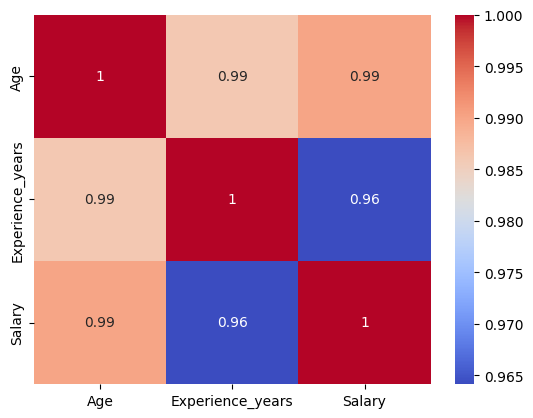

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(corr, annot=True, cmap="coolwarm") 
plt.show()

In [75]:
sal_data['Degree'].value_counts()

Degree
Bachelor    4
Master      3
PhD         3
Name: count, dtype: int64

<Axes: xlabel='Degree'>

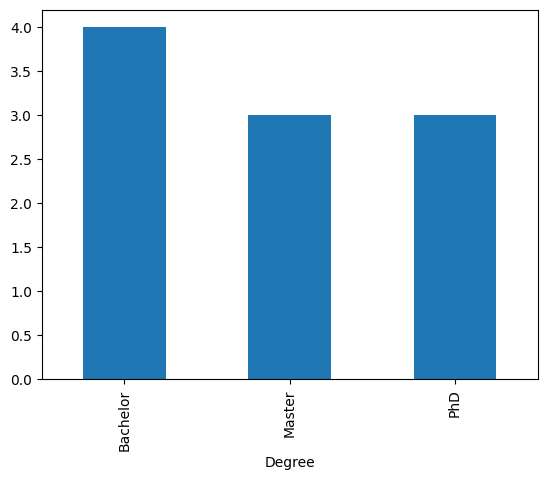

In [76]:
sal_data['Degree'].value_counts().plot(kind = 'bar')


In [77]:
sal_data['Job_title'].value_counts()

Job_title
IT         3
Finance    3
HR         2
Sales      2
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

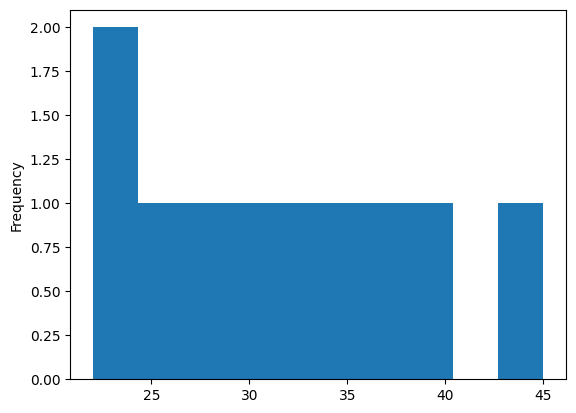

In [78]:
sal_data['Age'].plot(kind = 'hist')

<Axes: >

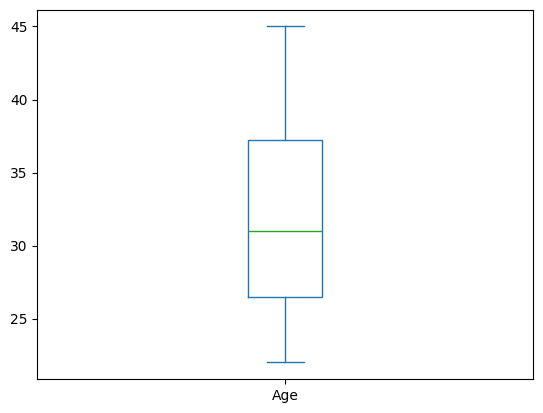

In [79]:
sal_data.Age.plot(kind = 'box')


<Axes: >

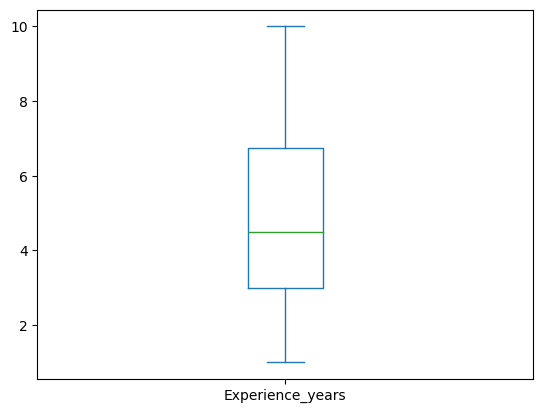

In [80]:
sal_data.Experience_years.plot(kind= 'box')

<Axes: >

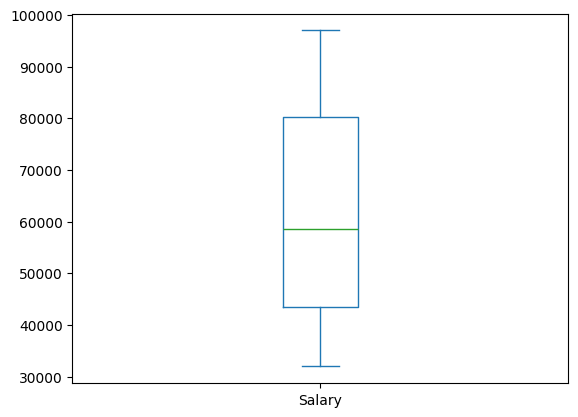

In [81]:
sal_data.Salary.plot(kind = 'box')

<Axes: ylabel='Frequency'>

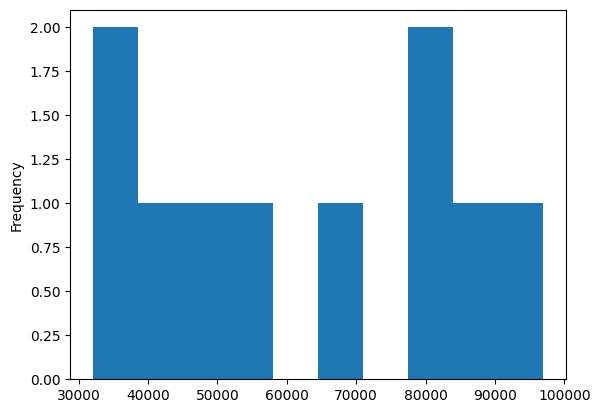

In [82]:
sal_data.Salary.plot(kind= 'hist')

#### Featuring Engineering

In [83]:
from sklearn.preprocessing import LabelEncoder
Label_Encoder = LabelEncoder()

In [84]:
sal_data['Degree_Encode'] = Label_Encoder.fit_transform(sal_data['Degree'])

In [85]:
sal_data['Job_title_Encode'] = Label_Encoder.fit_transform(sal_data['Job_title'])

In [86]:
sal_data.head()

,Experience_years,Degree,Age,Job_title,Salary,Degree_Encode,Job_title_Encode
0,1,Bachelor,22,IT,32000,0,2
1,3,Master,28,HR,45000,1,1
2,5,PhD,35,Finance,78000,2,0
3,2,Bachelor,24,IT,37000,0,2
4,6,Master,33,Sales,65000,1,3


In [87]:
from sklearn.preprocessing import StandardScaler
std_scaler  = StandardScaler()

In [88]:
sal_data['Age_scaled'] = std_scaler.fit_transform(sal_data[['Age']])
sal_data['Experience_years']=std_scaler.fit_transform(sal_data[['Experience_years']])

In [89]:
sal_data.drop(columns=['age_scaes'], inplace=True, errors='ignore')


In [90]:
sal_data.head()

,Experience_years,Degree,Age,Job_title,Salary,Degree_Encode,Job_title_Encode,Age_scaled
0,-1.444444,Bachelor,22,IT,32000,0,2,-1.408590
1,-0.703704,Master,28,HR,45000,1,1,-0.563436
2,0.037037,PhD,35,Finance,78000,2,0,0.422577
3,-1.074074,Bachelor,24,IT,37000,0,2,-1.126872
4,0.407407,Master,33,Sales,65000,1,3,0.140859


In [91]:
print(sal_data.columns.tolist())


['Experience_years', 'Degree', 'Age', 'Job_title', 'Salary', 'Degree_Encode', 'Job_title_Encode', 'Age_scaled']


In [92]:
x = sal_data[['Age_scaled','Degree_Encode','Job_title_Encode','Experience_years']]
y= sal_data['Salary']

In [93]:
x.head()

,Age_scaled,Degree_Encode,Job_title_Encode,Experience_years
0,-1.408590,0,2,-1.444444
1,-0.563436,1,1,-0.703704
2,0.422577,2,0,0.037037
3,-1.126872,0,2,-1.074074
4,0.140859,1,3,0.407407


In [94]:
from sklearn.model_selection import train_test_split

In [95]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [96]:
x_train.shape, y_train.shape

((8, 4), (8,))

In [97]:
x_test.shape, y_test.shape

((2, 4), (2,))

In [98]:
from sklearn.linear_model import LinearRegression

In [99]:
Linear_regression_model = LinearRegression()

In [100]:
Linear_regression_model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [101]:
y_pred_ir = Linear_regression_model.predict(x_test)
y_pred_ir

array([81371.09876015, 53569.04660111])

In [102]:
df = pd.DataFrame({'y_Actual' :y_test, 'y_predicted':y_pred_ir})
df['Error'] = df['y_Actual'] - df['y_predicted']
df['Error'] = df['y_Actual'] - df['y_predicted']
df

,y_Actual,y_predicted,Error
8,85000,81371.098760,3628.901240
1,45000,53569.046601,-8569.046601


In [103]:
df['abs_error'] = abs(df['Error'])
Mean_absolute_Error = df['abs_error'].mean()
df

,y_Actual,y_predicted,Error,abs_error
8,85000,81371.098760,3628.901240,3628.901240
1,45000,53569.046601,-8569.046601,8569.046601


In [104]:
#Model evaluation
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [105]:
r2_score(y_test, y_pred_ir)

0.8917531451742766

In [106]:
print(f'accuracy of the model = {round(r2_score(y_test, y_pred_ir),4)*100}%')

accuracy of the model = 89.18%


In [107]:
round(mean_absolute_error(y_test, y_pred_ir),2)

6098.97

In [108]:
print(f"Mean Absolute Error = {round(mean_absolute_error(y_test, y_pred_ir),2)}")

Mean Absolute Error = 6098.97


In [109]:
mse = round(mean_squared_error(y_test, y_pred_ir),2)
mse

43298741.93

In [110]:
print(f"Mean Squared Error = {round(mean_squared_error(y_test, y_pred_ir),2)}")

Mean Squared Error = 43298741.93


In [111]:
print('Root Mean Squared Error (RMSE) = ',mse**(0.5))

Root Mean Squared Error (RMSE) =  6580.177955800284


In [112]:
Linear_regression_model.coef_

array([21009.54472439,  4772.55237281,  -265.07054297, -4020.56434374])

In [113]:
sal_data.head()

,Experience_years,Degree,Age,Job_title,Salary,Degree_Encode,Job_title_Encode,Age_scaled
0,-1.444444,Bachelor,22,IT,32000,0,2,-1.408590
1,-0.703704,Master,28,HR,45000,1,1,-0.563436
2,0.037037,PhD,35,Finance,78000,2,0,0.422577
3,-1.074074,Bachelor,24,IT,37000,0,2,-1.126872
4,0.407407,Master,33,Sales,65000,1,3,0.140859


In [114]:

Age = 49
Degree =2
Job_title = 2
Experience_years =2


In [115]:
Linear_regression_model.intercept_

np.float64(58069.81616075246)

In [116]:
std_scaler.transform([[15]])[0][0]

C:\Users\Hp ProBook 440\python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float64(3.7407407407407405)

In [117]:
Emp_Salary = Linear_regression_model.predict([[Age,  Degree, Job_title, Experience_years]])
Emp_Salary

C:\Users\Hp ProBook 440\python\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1088511.34262787])

In [118]:
print("Salary of that Employee with above attribution =", Emp_Salary[0])

Salary of that Employee with above attribution = 1088511.3426278713
